Dataset: The simulated dataset ([here](https://zenodo.org/))

In [1]:
import os
import sys
adata_input_path = 'simulation/data/strip_psudospot_truth_dropout.h5ad'
pretrain_input_path = 'simulation/peak_ref.h5ad'
adata_output_path = './simulation_out'

In [2]:
import SPEED
import scanpy as sc

/home/lifesci/wangshuyan/miniconda3/envs/pytorch/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
adata = sc.read(adata_input_path)
adata_peak = sc.read(pretrain_input_path)

In [4]:
adata,adata_sc = SPEED.process(adata,adata_peak,min_cells_ratio=0.01)

In [6]:
adata_sc

View of AnnData object with n_obs × n_vars = 133140 × 29003
    obs: 'Sample', 'Clusters', 'val'
    var: 'val'
    obsm: 'cell_SPEED'
    varm: 'peak_SPEED'

In [7]:
speed = SPEED.SPEED(adata,image=None,k_degree=5, is_spatial=True, adata_sc=adata_sc)

matrix ready...
use 0-1 matrix...
cell_features ready...
peak features ready...


In [8]:
speed.setup_data(num_workers=4)

split ready...
labels ready...
peak embedding is given
dataset ready...


In [9]:
speed.build_model(emb_features=32)

In [ ]:
speed.train(device=device,save=False)

In [11]:
torch.save(speed.model.state_dict(), f'simulation_out/model_cpu.pth')

In [12]:
adata = speed.get_embedding(adata)

get cell/spot embedding...


100%|██████████| 5/5 [00:00<00:00, 132.50it/s]


get peak embedding...


100%|██████████| 5/5 [00:00<00:00, 115.70it/s]

get spatial embedding...


In [13]:
adata.X = speed.get_denoise_result()

In [14]:
sc.pp.neighbors(adata, use_rep='X_SPEED', random_state=1)
sc.tl.umap(adata)
sc.tl.leiden(adata, random_state=1, key_added="leiden_spot",resolution=0.2)

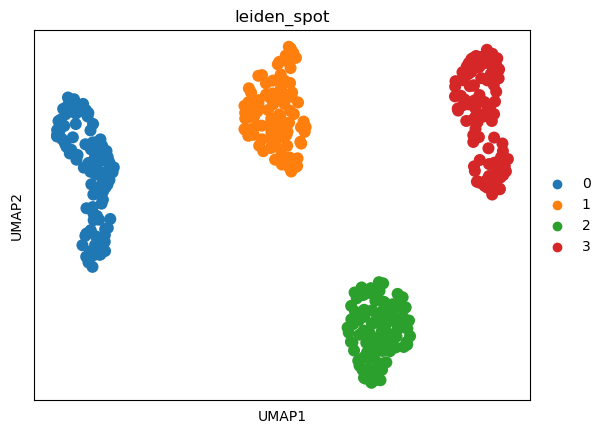

In [15]:
sc.pl.umap(adata,color='leiden_spot')

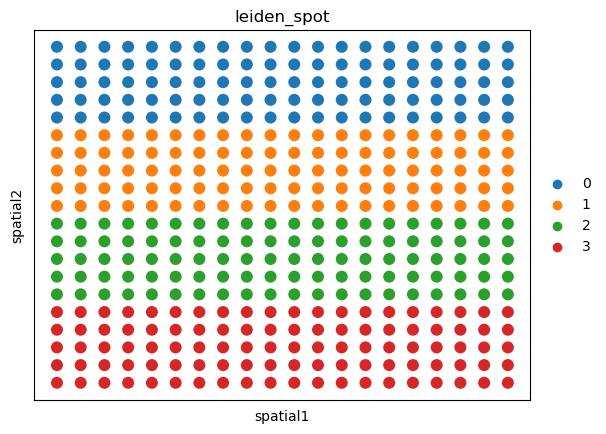

In [16]:
sc.pl.embedding(adata,basis='spatial',color='leiden_spot')

In [17]:
plot = ['chr16:29893731-29894231','chr4:42860430-42860930','chr4:53797048-53797548','chr6:16727179-16727679']

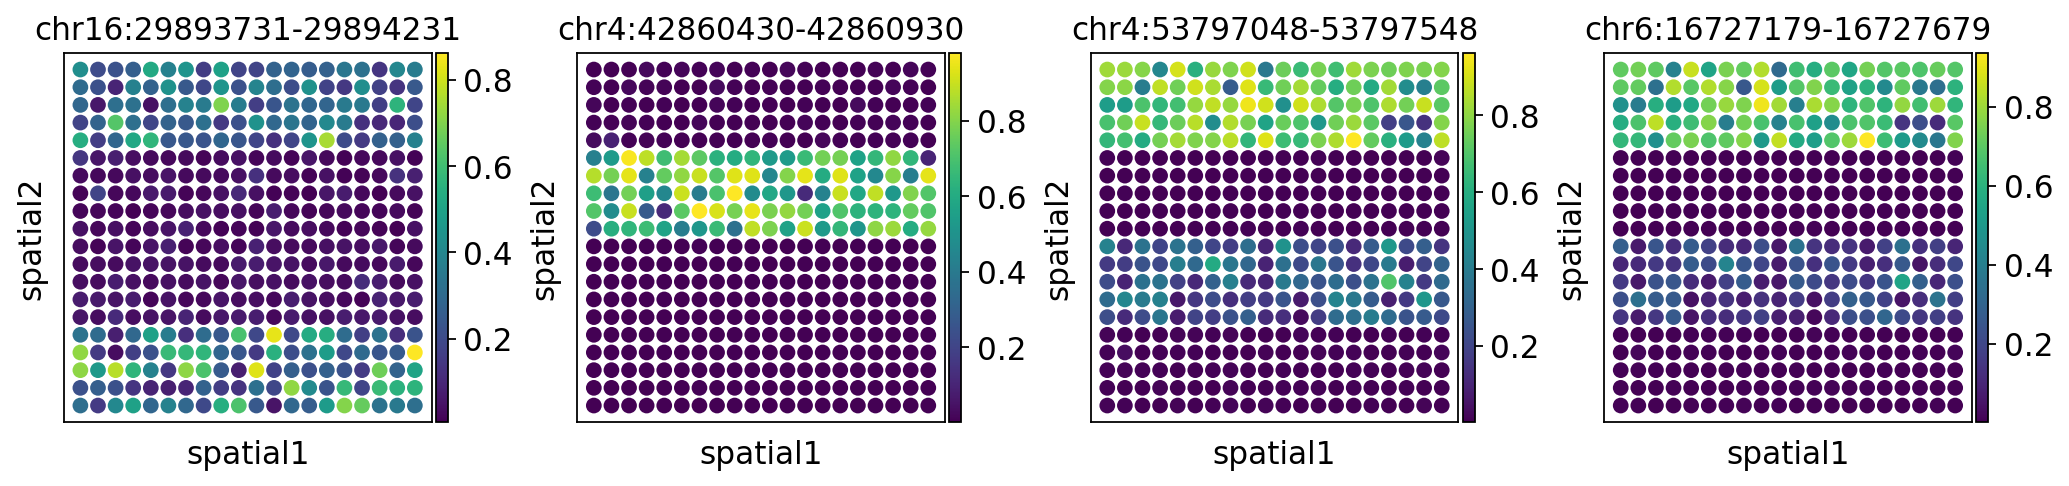

In [18]:
sc.set_figure_params(figsize=(3,3))
sc.pl.embedding(adata,color=plot,basis='spatial',ncols=4,s=200)

In [19]:
adata = speed.binarize(adata)

100%|██████████| 29003/29003 [00:03<00:00, 8800.55it/s]


In [20]:
adata.write(f'simulation_out/adata_speed_cpu.h5ad')

In [21]:
adata.X=adata.obsm['binary_SPEED']

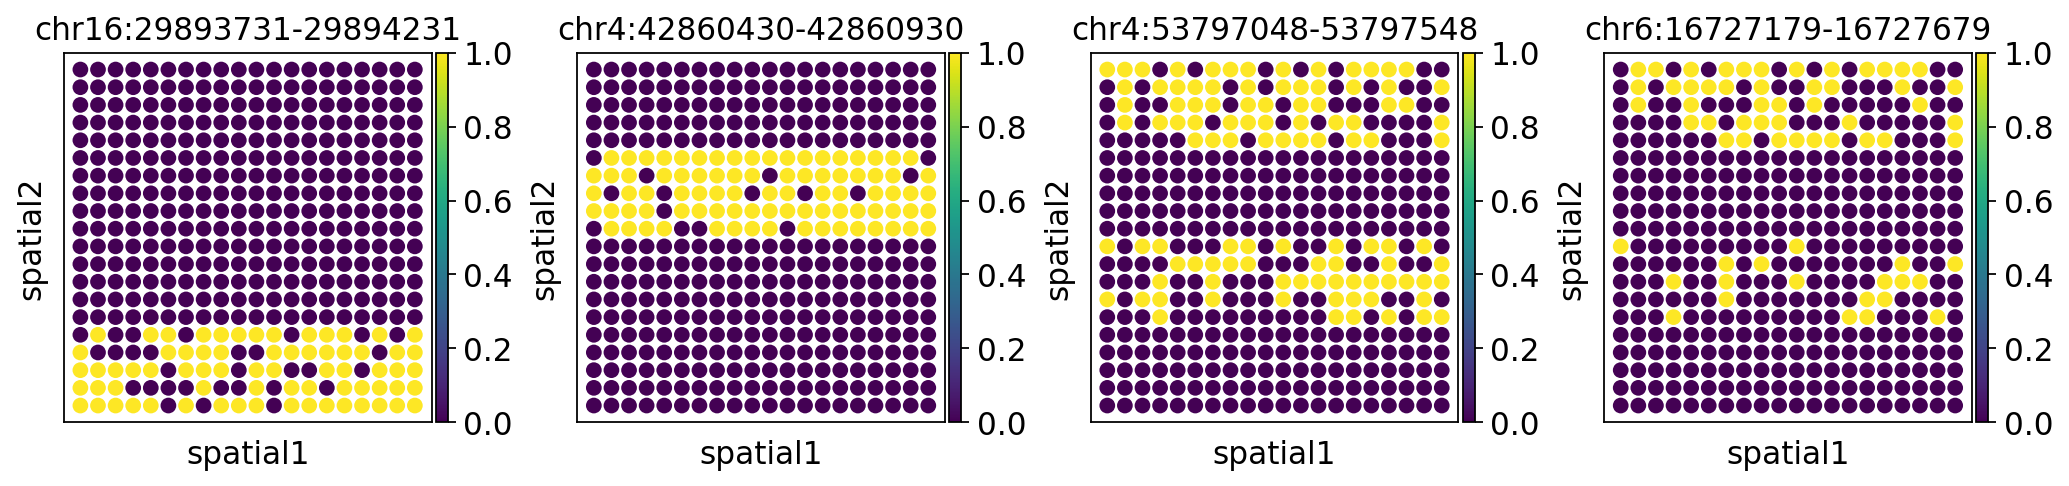

In [22]:
sc.set_figure_params(figsize=(3,3))
sc.pl.embedding(adata,color=plot,basis='spatial',ncols=5,s=200)